# Visualize HPE Results from moveEnet_flowKalman.cpp

This notebook loads predictions from CSV (eval_format) and ground truth from YARP log, computes metrics (PCK, RMSE, MPJPE), and visualizes joint trajectories, skeleton overlays, and PCK curves for dataset cam2_S1_Discussion_ch0.

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from pathlib import Path
from datasets.utils import constants as ds_constants, parsing as ds_parsing
from evaluation.utils import metrics as metrics_utils


# Load CSV Data

In [2]:
pred_path = '/home/moveEnetFlow/csv_file/test_pwr.csv'
predictions = np.loadtxt(pred_path, delimiter=',', skiprows=1)
ncols = predictions.shape[1]
ts_pred = predictions[:, 0]

# Detect CSV layout (eval_format vs non-eval)
if ncols in (28, 54):
    # eval_format: ts, latency, 26 coords (x0,y0,...,x12,y12) [+ 26 velocities optional]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    csv_layout = 'eval_format'
elif (ncols - 1) % 5 == 0:
    # non-eval: ts, then per-joint x,y,vx,vy,conf (5 values each)
    lat_pred = np.zeros_like(ts_pred)
    joints_pred = np.zeros((len(ts_pred), 13, 2))
    for j in range(13):
        base = 1 + j * 5
        joints_pred[:, j, 0] = predictions[:, base]
        joints_pred[:, j, 1] = predictions[:, base + 1]
    csv_layout = 'non_eval'
else:
    raise ValueError(f'Unrecognized CSV format with {ncols} columns: {pred_path}')

print(f"Loaded {len(ts_pred)} prediction frames ({csv_layout}, cols={ncols})")

Loaded 8245 prediction frames (eval_format, cols=28)


In [3]:
# OFK_offline.csv'
predictions = np.loadtxt(pred_path, delimiter=',', skiprows=1)
ncols = predictions.shape[1]
ts_pred = predictions[:, 0]

# Detect CSV layout (eval_format vs non-eval)
if ncols in (28, 54):
    # eval_format: ts, latency, 26 coords (x0,y0,...,x12,y12) [+ 26 velocities optional]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    csv_layout = 'eval_format'
elif (ncols - 1) % 5 == 0:
    # non-eval: ts, then per-joint x,y,vx,vy,conf (5 values each)
    lat_pred = np.zeros_like(ts_pred)
    joints_pred = np.zeros((len(ts_pred), 13, 2))
    for j in range(13):
        base = 1 + j * 5
        joints_pred[:, j, 0] = predictions[:, base]
        joints_pred[:, j, 1] = predictions[:, base + 1]
    csv_layout = 'non_eval'
else:
    raise ValueError(f'Unrecognized CSV format with {ncols} columns: {pred_path}')

print(f"Loaded {len(ts_pred)} prediction frames ({csv_layout}, cols={ncols})")

Loaded 8245 prediction frames (eval_format, cols=28)


# Load Log Data

In [4]:
gt_path = Path('/data/new_scarfGNN_full/raw/cam2_S8_Discussion/ch0GT200Hzskeleton/data.log')
data = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
print(f"Loaded GT data with {len(data['ts'])} frames")

Loaded GT data with 8253 frames


# Extract Joint Trajectories

In [5]:
ts_gt = np.concatenate(([0.0], data['ts'], [data['ts'][-1] + 1]))
for joint_key in ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys():
    x_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 0]], data[joint_key][:, 0], [data[joint_key][-1, 0]])))
    y_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 1]], data[joint_key][:, 1], [data[joint_key][-1, 1]])))
    data[joint_key] = {'x': x_interp, 'y': y_interp}

joints_gt = np.zeros((len(ts_pred), 13, 2))
joint_list = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, ts in enumerate(ts_pred):
    for j, joint in enumerate(joint_list):
        joints_gt[i, j, 0] = data[joint]['x'](ts)
        joints_gt[i, j, 1] = data[joint]['y'](ts)
print("Extracted GT joint trajectories")

Extracted GT joint trajectories


# Compute PCK Metric

In [6]:
if data['head_sizes'][0] != -1:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['head_sizes'][0]], data['head_sizes'], [data['head_sizes'][-1]])))
else:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['torso_sizes'][0]], data['torso_sizes'], [data['torso_sizes'][-1]])))
pck_sizes = pck_sizes_interp(ts_pred)

thresholds = [0.2,0.25,0.3,0.35, 0.4,0.45,0.5,0.55, 0.6]
pck_results = {}
for th in thresholds:
    pck_metric = metrics_utils.PCK(th)
    pck_metric.update_samples(joints_pred, joints_gt, pck_sizes)
    pck_results[th] = {'avg': pck_metric.get_value()}

print("PCK Results Summary:")
print("-" * 30)
for th in thresholds:
    overall_pck = pck_results[th]['avg'][1] * 100  # Overall PCK in percentage
    print(f"Threshold {th:.2f}: {overall_pck:.2f}%")
print("-" * 30)

PCK Results Summary:
------------------------------
Threshold 0.20: 98.22%
Threshold 0.25: 99.02%
Threshold 0.30: 99.45%
Threshold 0.35: 99.68%
Threshold 0.40: 99.83%
Threshold 0.45: 99.95%
Threshold 0.50: 99.97%
Threshold 0.55: 99.99%
Threshold 0.60: 100.00%
------------------------------


# Compute RMSE Metric

In [7]:
rmse_metric = metrics_utils.RMSE()
rmse_metric.update_samples(joints_pred, joints_gt)
rmse_results = rmse_metric.get_value()

print("RMSE Results Summary:")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    rmse_val = rmse_results[2][i]  # Per-joint RMSE
    print(f"{name}: {rmse_val:.2f} pixels")
print("-" * 40)
print(f"Total Average RMSE: {rmse_results[2].mean():.2f} pixels")
print("-" * 40)

RMSE Results Summary:
----------------------------------------
head: 2.11 pixels
shoulder_right: 2.50 pixels
shoulder_left: 2.28 pixels
elbow_right: 2.90 pixels
elbow_left: 2.80 pixels
hip_left: 1.22 pixels
hip_right: 1.15 pixels
wrist_right: 6.48 pixels
wrist_left: 5.53 pixels
knee_right: 1.16 pixels
knee_left: 1.09 pixels
ankle_right: 1.63 pixels
ankle_left: 1.54 pixels
----------------------------------------
Total Average RMSE: 2.49 pixels
----------------------------------------


# RMSE Boxplot

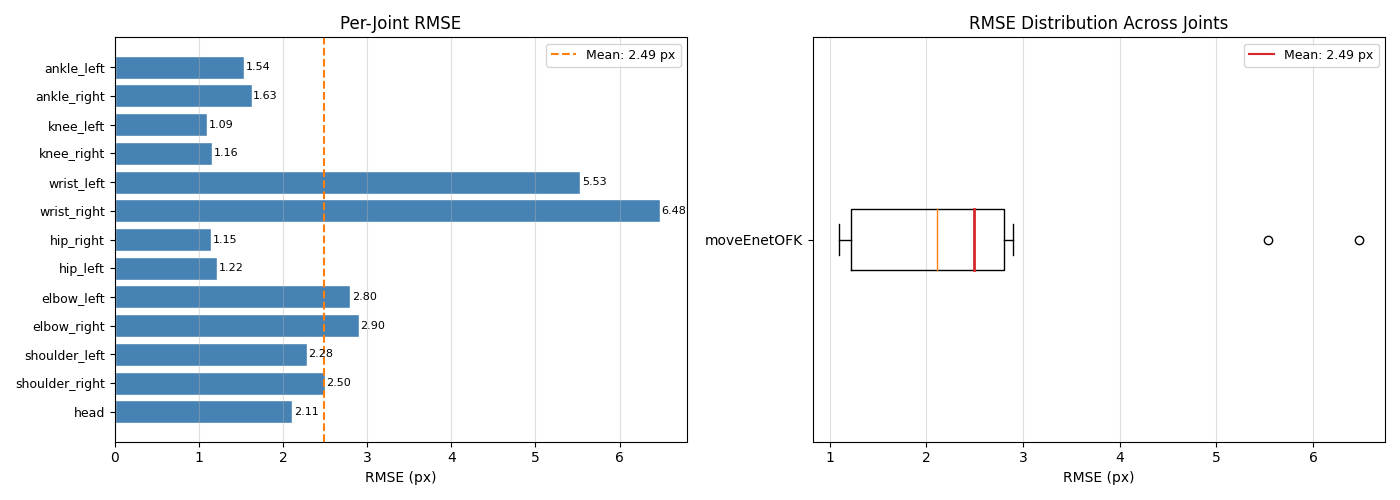

In [8]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
rmse_vals = rmse_results[2]  # shape (13,) - per-joint combined RMSE

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-joint horizontal bar chart ---
y_pos = np.arange(len(joint_names))
bars = ax_bar.barh(y_pos, rmse_vals, color='steelblue', edgecolor='white')
ax_bar.axvline(rmse_vals.mean(), color='tab:orange', linestyle='--', linewidth=1.5,
               label=f'Mean: {rmse_vals.mean():.2f} px')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(joint_names, fontsize=9)
ax_bar.set_xlabel('RMSE (px)')
ax_bar.set_title('Per-Joint RMSE')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, rmse_vals):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

# --- Right: boxplot showing distribution across joints ---
meanlineprops = dict(linestyle='-', linewidth=2.0, color='tab:red')
ax_box.boxplot([rmse_vals], vert=False, showfliers=True, showmeans=True,
               meanline=True, meanprops=meanlineprops)
ax_box.set_yticks([1])
ax_box.set_yticklabels(['moveEnetOFK'])
ax_box.set_xlabel('RMSE (px)')
ax_box.set_title('RMSE Distribution Across Joints')
ax_box.grid(axis='x', alpha=0.4)
# Legend for mean line in boxplot
ax_box.plot([], [], color='tab:red', linestyle='-', linewidth=1.5, label=f'Mean: {rmse_vals.mean():.2f} px')
ax_box.legend(fontsize=9) 

plt.tight_layout()
plt.show()


# Per-Joint Error Over Time

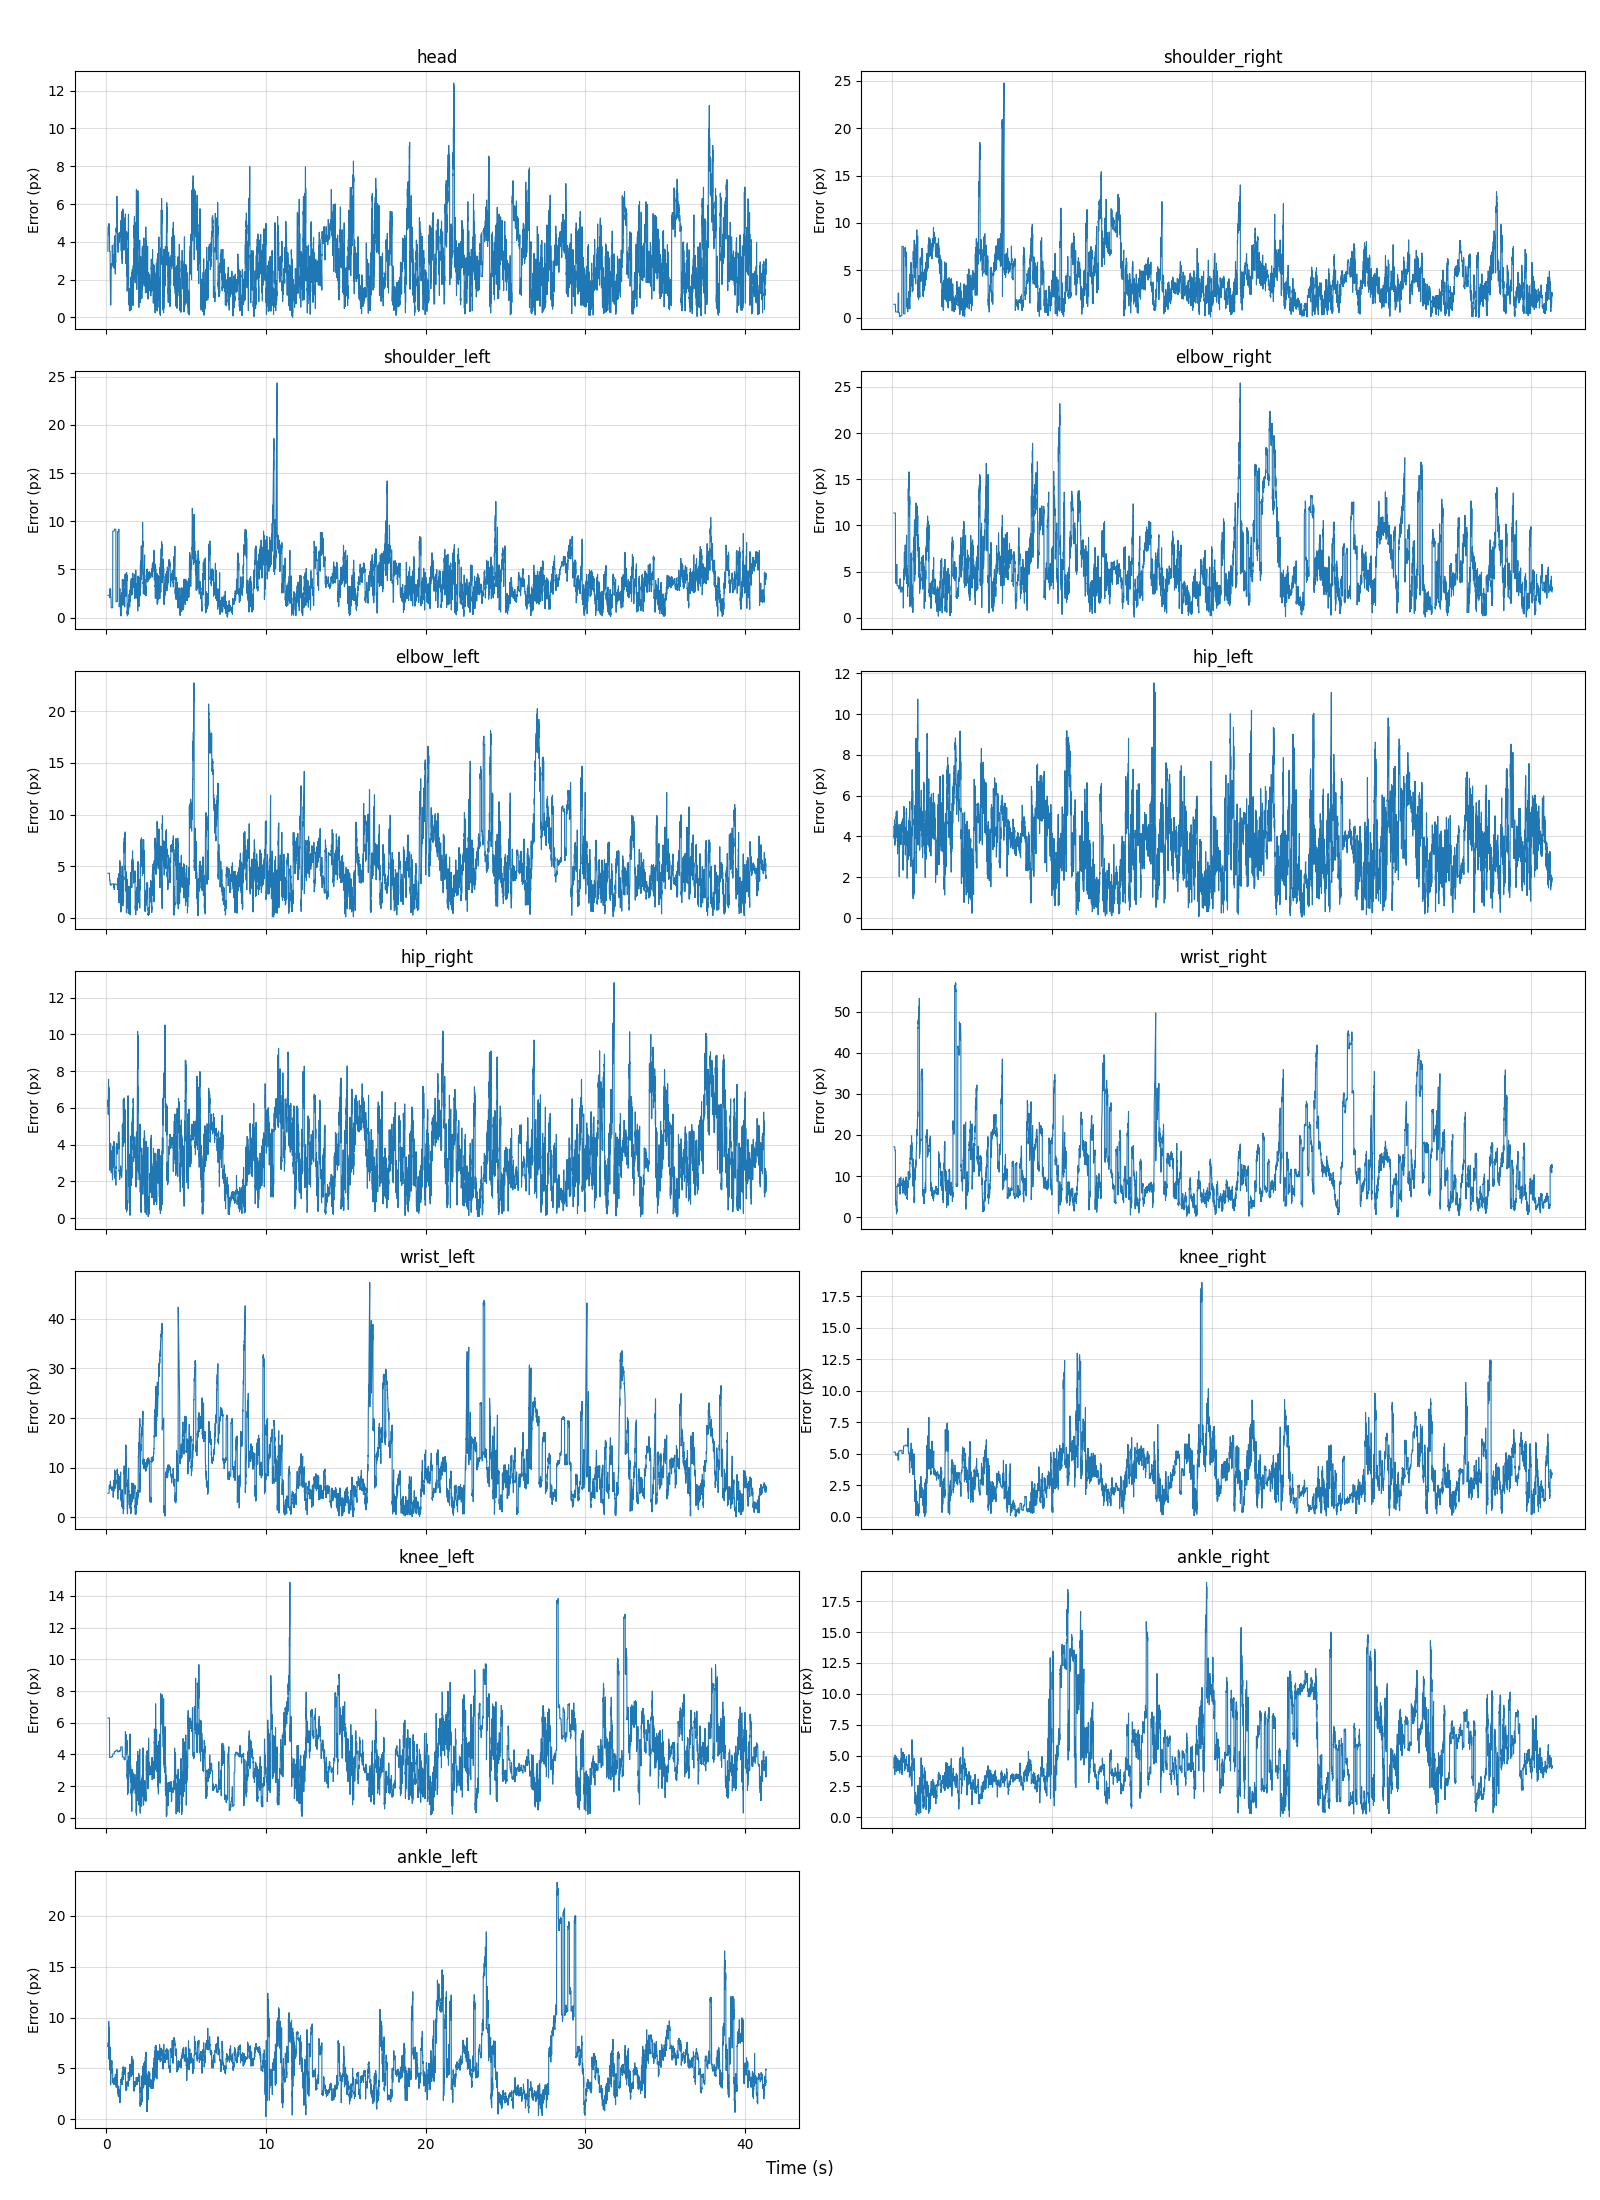

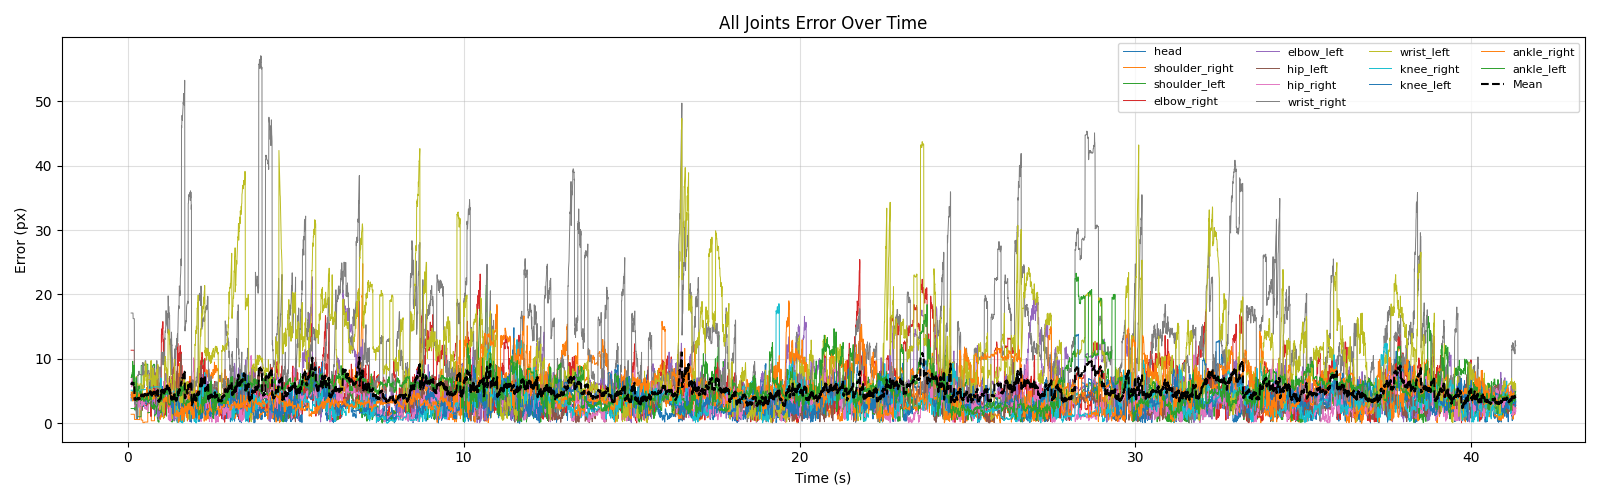

In [9]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

# Per-joint Euclidean error over time: shape (N_frames, 13)
errors = np.linalg.norm(joints_pred - joints_gt, axis=2)

fig, axes = plt.subplots(7, 2, figsize=(16, 22), sharex=True)
axes = axes.flatten()

for j in range(13):
    axes[j].plot(ts_pred, errors[:, j], linewidth=0.8)
    axes[j].set_title(joint_names[j])
    axes[j].set_ylabel('Error (px)')
    axes[j].grid(True, alpha=0.4)

# Hide the unused 14th subplot
axes[13].axis('off')

fig.suptitle('Per-Joint Euclidean Error Over Time', fontsize=14, y=1.01)
fig.supxlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()

# Also plot all joints on a single axes for overview
fig2, ax = plt.subplots(figsize=(16, 5))
for j in range(13):
    ax.plot(ts_pred, errors[:, j], linewidth=0.7, label=joint_names[j])
ax.plot(ts_pred, errors.mean(axis=1), color='black', linewidth=1.5, linestyle='--', label='Mean')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Error (px)')
ax.set_title('All Joints Error Over Time')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# Compute MPJPE Metric

In [10]:
mpjpe_metric = metrics_utils.MPJPE()
mpjpe_metric.update_samples(joints_pred, joints_gt)
mpjpe_results = mpjpe_metric.get_value()

print("MPJPE Results Summary:")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    mpjpe_val = mpjpe_results[0][i]  # Per-joint MPJPE
    print(f"{name}: {mpjpe_val:.2f} pixels")
print("-" * 40)
print(f"Total Average MPJPE: {mpjpe_results[1]:.2f} pixels")
print("-" * 40)

MPJPE Results Summary:
----------------------------------------
head: 2.89 pixels
shoulder_right: 3.86 pixels
shoulder_left: 3.75 pixels
elbow_right: 5.72 pixels
elbow_left: 5.12 pixels
hip_left: 3.67 pixels
hip_right: 3.48 pixels
wrist_right: 11.95 pixels
wrist_left: 10.14 pixels
knee_right: 3.35 pixels
knee_left: 3.91 pixels
ankle_right: 5.15 pixels
ankle_left: 5.51 pixels
----------------------------------------
Total Average MPJPE: 5.27 pixels
----------------------------------------


# MPJPE Boxplot

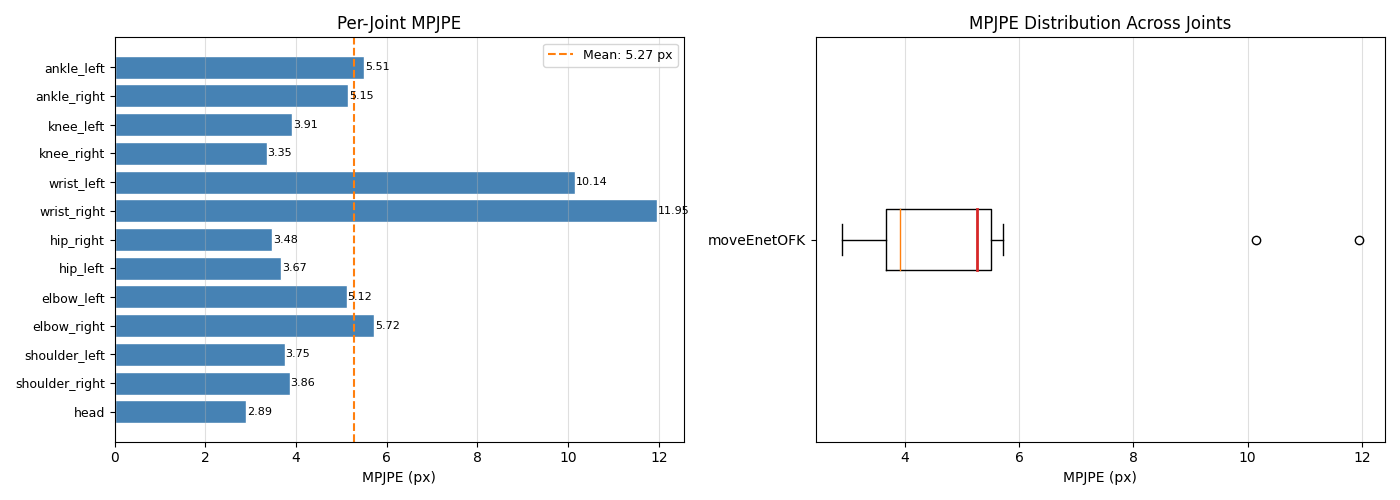

In [11]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
mpjpe_per_joint = mpjpe_results[0]  # shape (13,) - per-joint MPJPE

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-joint horizontal bar chart ---
y_pos = np.arange(len(joint_names))
bars = ax_bar.barh(y_pos, mpjpe_per_joint, color='steelblue', edgecolor='white')
ax_bar.axvline(mpjpe_per_joint.mean(), color='tab:orange', linestyle='--', linewidth=1.5,
               label=f'Mean: {mpjpe_per_joint.mean():.2f} px')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(joint_names, fontsize=9)
ax_bar.set_xlabel('MPJPE (px)')
ax_bar.set_title('Per-Joint MPJPE')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, mpjpe_per_joint):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

# --- Right: boxplot showing distribution across joints ---
meanlineprops = dict(linestyle='-', linewidth=2.0, color='tab:red', label=f'Mean: {mpjpe_per_joint.mean():.2f} px')
ax_box.boxplot([mpjpe_per_joint], vert=False, showfliers=True, showmeans=True,
               meanline=True, meanprops=meanlineprops)
ax_box.set_yticks([1])
ax_box.set_yticklabels(['moveEnetOFK'])
ax_box.set_xlabel('MPJPE (px)')
ax_box.set_title('MPJPE Distribution Across Joints')
ax_box.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()


# Generate PCK Curves

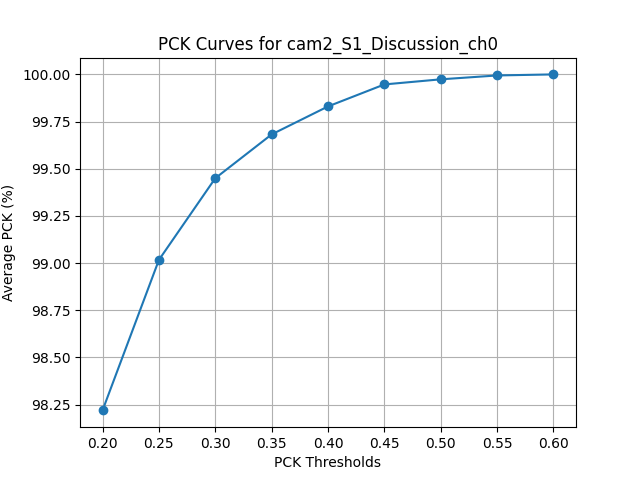

In [12]:
# thresholds = [0.2, 0.4, 0.6]
pck_vals = [pck_results[th]['avg'][1] * 100 for th in thresholds]  # to percentage, take overall avg
plt.figure()
plt.plot(thresholds, pck_vals, marker='o')
plt.xlabel('PCK Thresholds')
plt.ylabel('Average PCK (%)')
plt.title('PCK Curves for cam2_S1_Discussion_ch0')
plt.grid(True)
plt.show()

# Visualize Skeleton Overlays

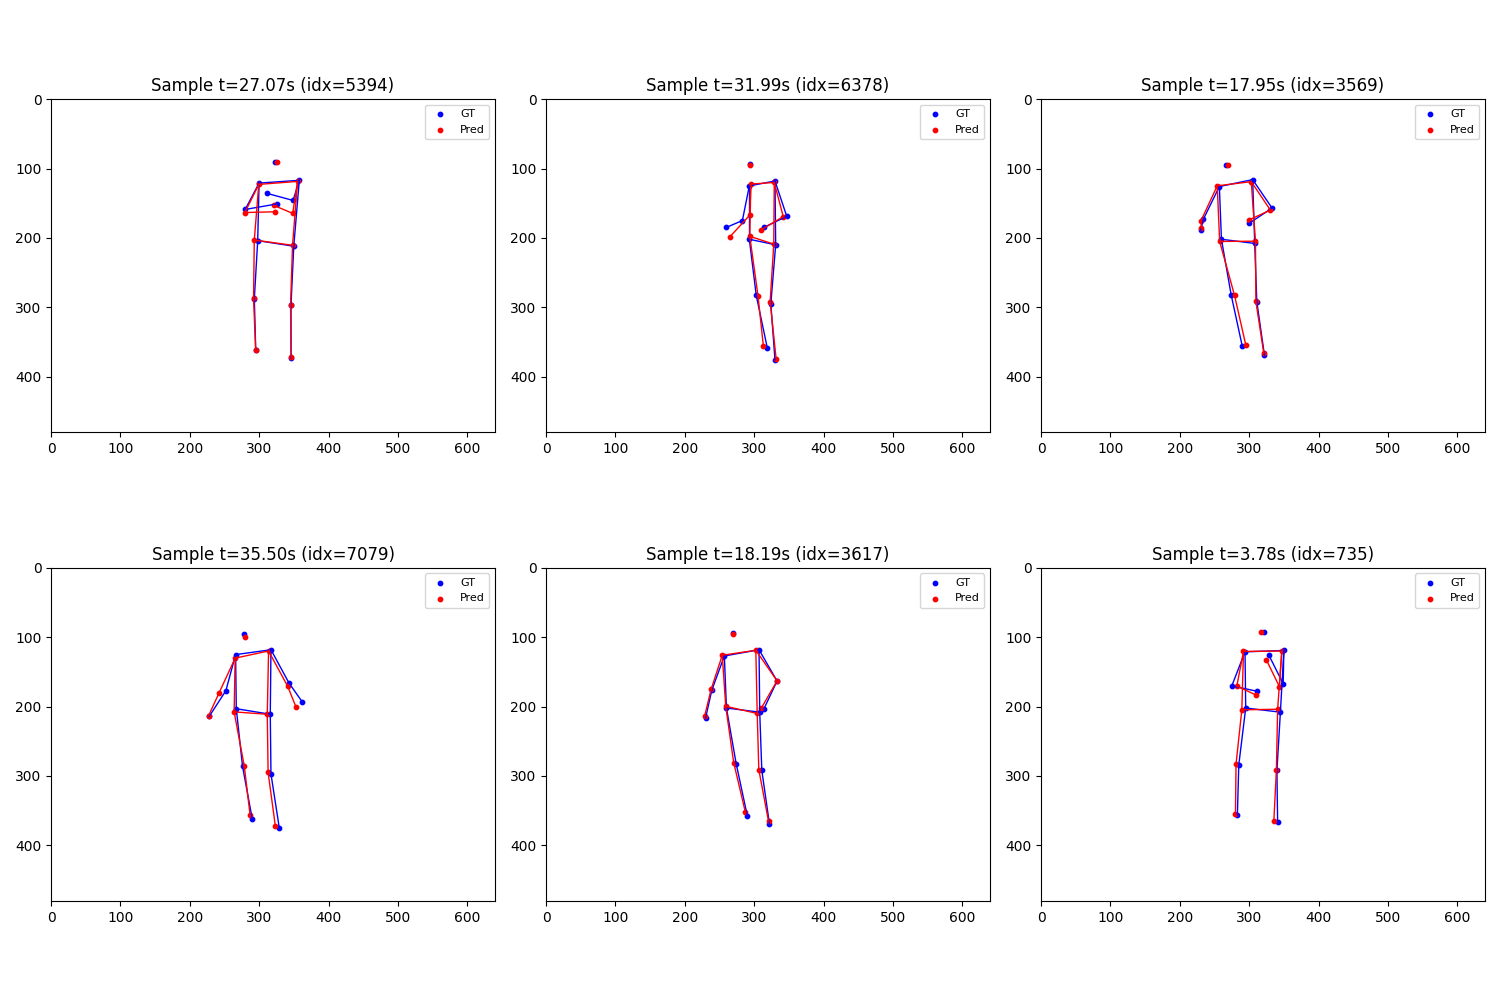

In [13]:
# Define skeleton connections (example, adjust as needed)
skeleton_connections = [
    (1, 2),   # shoulder_right to shoulder_left
    (1, 3),   # shoulder_right to elbow_right
    (1, 6),   # shoulder_right to hip_right
    (2, 4),   # shoulder_left to elbow_left
    (2, 5),   # shoulder_left to hip_left
    (3, 7),   # elbow_right to wrist_right
    (4, 8),   # elbow_left to wrist_left
    (5, 6),   # hip_left to hip_right
    (5, 10),  # hip_left to knee_left
    (6, 9),   # hip_right to knee_right
    (9, 11),  # knee_right to ankle_right
    (10, 12)  # knee_left to ankle_left
 ]

num_samples = 6
total_frames = len(ts_pred)
if total_frames == 0:
    raise ValueError('No prediction frames available to plot')

rng = np.random.default_rng(42)
sample_count = min(num_samples, total_frames)
sample_indices = rng.choice(total_frames, size=sample_count, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax_i, idx in enumerate(sample_indices):
    ax = axes[ax_i]
    # Plot GT
    for j in range(13):
        ax.scatter(joints_gt[idx, j, 0], joints_gt[idx, j, 1], c='blue', s=10, label='GT' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_gt[idx, conn[0], 0], joints_gt[idx, conn[1], 0]],
                [joints_gt[idx, conn[0], 1], joints_gt[idx, conn[1], 1]], c='blue', linewidth=1)
    # Plot Pred
    for j in range(13):
        ax.scatter(joints_pred[idx, j, 0], joints_pred[idx, j, 1], c='red', s=10, label='Pred' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_pred[idx, conn[0], 0], joints_pred[idx, conn[1], 0]],
                [joints_pred[idx, conn[0], 1], joints_pred[idx, conn[1], 1]], c='red', linewidth=1)

    ax.set_title(f'Sample t={ts_pred[idx]:.2f}s (idx={idx})')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.legend(loc='upper right', fontsize=8)

# Hide any unused subplots if < 6 samples
for k in range(sample_count, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

# Latency Over Time

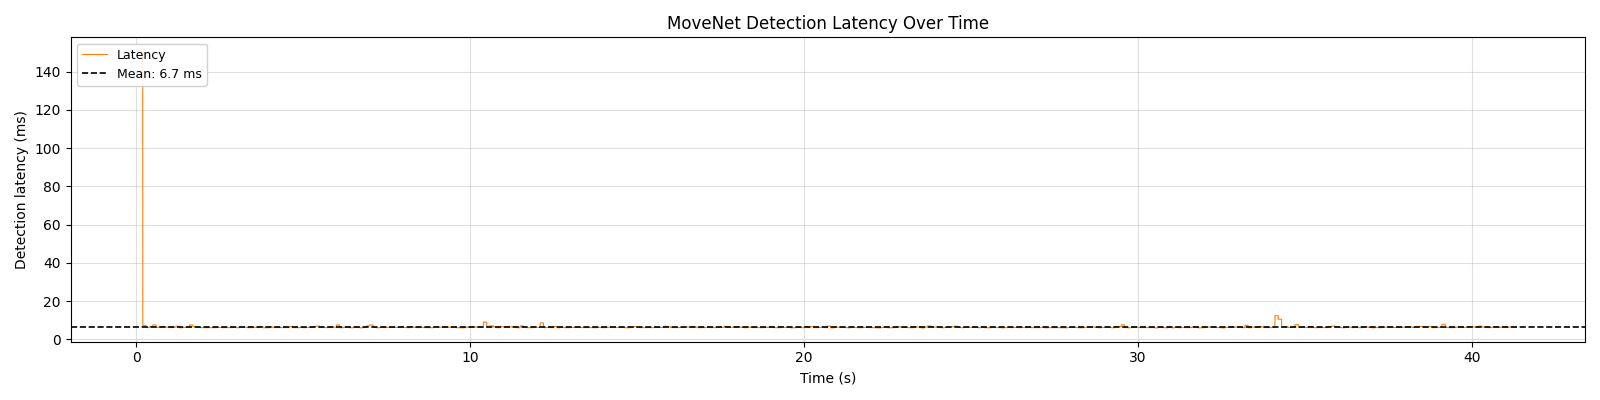

Avg latency: 6.69 ms  |  Min: 5.98 ms  |  Max: 150.77 ms


In [14]:
if csv_layout == 'eval_format':
    fig, ax = plt.subplots(figsize=(16, 4))
    # lat_pred is in seconds (as stored by the C++ code); convert to ms
    ax.plot(ts_pred, lat_pred * 1000, linewidth=0.8, color='tab:orange', label='Latency')
    ax.axhline(np.mean(lat_pred) * 1000, color='black', linestyle='--',
               linewidth=1.2, label=f'Mean: {np.mean(lat_pred)*1000:.1f} ms')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Detection latency (ms)')
    ax.set_title('MoveNet Detection Latency Over Time')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f"Avg latency: {np.mean(lat_pred)*1000:.2f} ms  |  "
          f"Min: {np.min(lat_pred)*1000:.2f} ms  |  Max: {np.max(lat_pred)*1000:.2f} ms")

else:
    print("Latency data not available (CSV was not recorded in eval_format).")


# Per-Joint x(t) / y(t) Coordinate Trajectories

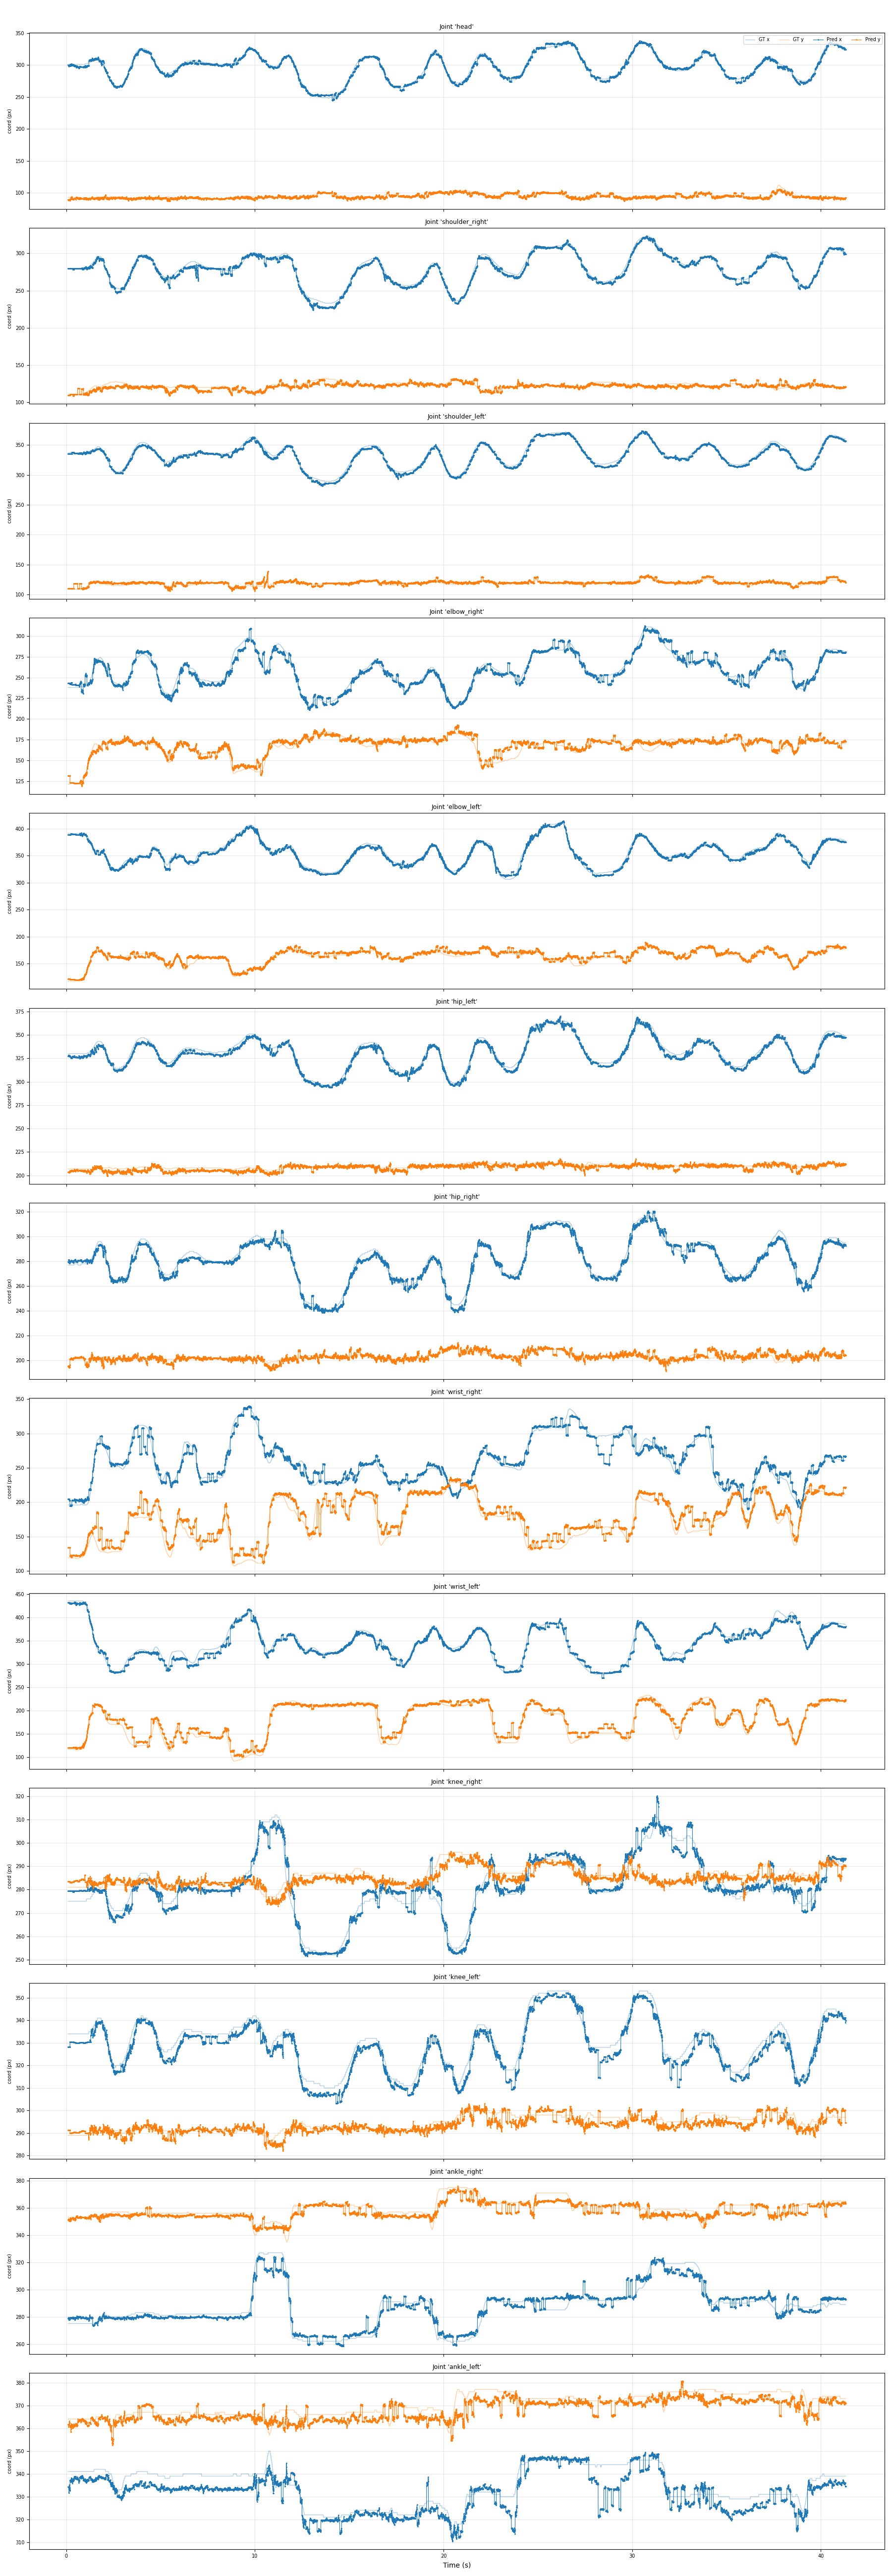

In [15]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

# One subplot per joint: x(t) and y(t) for GT and prediction
fig, axes = plt.subplots(13, 1, figsize=(18, 52), sharex=True)

for j, (name, ax) in enumerate(zip(joint_names, axes)):
    # GT
    ax.plot(ts_pred, joints_gt[:, j, 0], color='tab:blue',  alpha=0.35, linewidth=1.0, label='GT x')
    ax.plot(ts_pred, joints_gt[:, j, 1], color='tab:orange', alpha=0.35, linewidth=1.0, label='GT y')
    # Prediction
    ax.plot(ts_pred, joints_pred[:, j, 0], color='tab:blue',  alpha=1.0, linewidth=0.8,
            linestyle='-', marker='.', markersize=2, label='Pred x')
    ax.plot(ts_pred, joints_pred[:, j, 1], color='tab:orange', alpha=1.0, linewidth=0.8,
            linestyle='-', marker='.', markersize=2, label='Pred y')
    ax.set_title(f"Joint '{name}'", fontsize=9)
    ax.set_ylabel('coord (px)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.legend(fontsize=7, loc='upper right', ncol=4)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Per-Joint Coordinate Trajectories Over Time (GT faded, Pred solid)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


# PowerJoular Analysis

These cells load PowerJoular CSV outputs (e.g., `test_pwr-*.csv`) and generate useful diagnostics: timeline, distribution, cumulative energy, and run-to-run comparison.


In [16]:
import csv
from datetime import datetime
from pathlib import Path

# Folder and pattern for PowerJoular CSV files
pj_dir = Path('/home/moveEnetFlow/pwr_file')
pj_pattern = '*.csv'

def load_powerjoular_csv(path):
    rows = []
    with open(path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            ts = datetime.strptime(row['Date'].strip(), '%Y-%m-%d %H:%M:%S.%f')
            util = float(row.get('CPU Utilization', 0.0))
            pwr = float(row.get('CPU Power', 0.0))
            rows.append((ts, util, pwr))

    if not rows:
        raise ValueError(f'No rows found in {path}')

    t0 = rows[0][0]
    t_sec = np.array([(r[0] - t0).total_seconds() for r in rows], dtype=float)
    util = np.array([r[1] for r in rows], dtype=float)
    power = np.array([r[2] for r in rows], dtype=float)

    # Integrate power over time -> Joules
    energy_j = np.trapz(power, t_sec) if len(t_sec) > 1 else 0.0

    return {
        'path': path,
        't_sec': t_sec,
        'util': util,
        'power': power,
        'energy_j': energy_j,
        'duration_s': float(t_sec[-1] - t_sec[0]) if len(t_sec) > 1 else 0.0
    }

pj_files = sorted(pj_dir.glob(pj_pattern))
if not pj_files:
    raise FileNotFoundError(f'No PowerJoular CSV files found in {pj_dir} with pattern {pj_pattern!r}')

pj_runs = [load_powerjoular_csv(p) for p in pj_files]
print(f'Loaded {len(pj_runs)} PowerJoular files from {pj_dir}')
for r in pj_runs:
    print(f'- {r["path"].name}: duration={r["duration_s"]:.2f}s, energy={r["energy_j"]:.2f}J, mean_power={r["power"].mean():.2f}W')


Loaded 3 PowerJoular files from /home/moveEnetFlow/pwr_file
- test_pwr-458092.csv: duration=26.68s, energy=1205.58J, mean_power=43.60W
- test_pwr-475047.csv: duration=28.39s, energy=1245.56J, mean_power=43.39W
- test_pwr-506310.csv: duration=7.11s, energy=146.27J, mean_power=21.02W


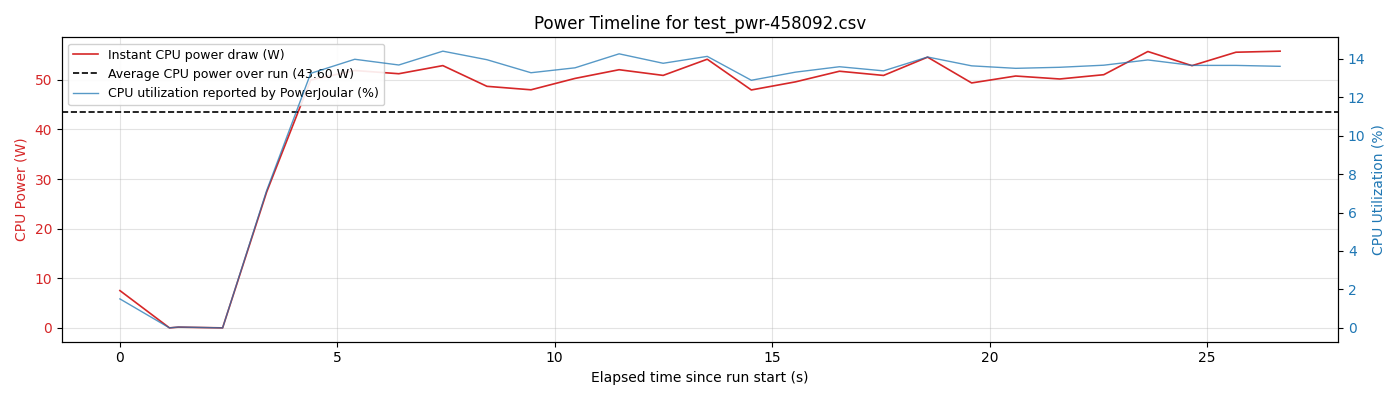

In [17]:
# Select which run to visualize in detail
pj_idx = 0
run = pj_runs[pj_idx]

fig, ax1 = plt.subplots(figsize=(14, 4))

# Power trace (left axis)
power_line, = ax1.plot(
    run['t_sec'], run['power'], color='tab:red', linewidth=1.2,
    label='Instant CPU power draw (W)'
)
mean_power = run['power'].mean()
mean_line = ax1.axhline(
    mean_power, color='black', linestyle='--', linewidth=1.2,
    label=f'Average CPU power over run ({mean_power:.2f} W)'
)
ax1.set_xlabel('Elapsed time since run start (s)')
ax1.set_ylabel('CPU Power (W)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, alpha=0.35)

# Utilization trace (right axis)
ax2 = ax1.twinx()
util_line, = ax2.plot(
    run['t_sec'], run['util'] * 100.0, color='tab:blue', linewidth=1.0, alpha=0.75,
    label='CPU utilization reported by PowerJoular (%)'
)
ax2.set_ylabel('CPU Utilization (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Combined legend from both axes for readability
lines = [power_line, mean_line, util_line]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, fontsize=9, loc='upper left', framealpha=0.9)

plt.title(f"Power Timeline for {run['path'].name}")
fig.tight_layout()
plt.show()


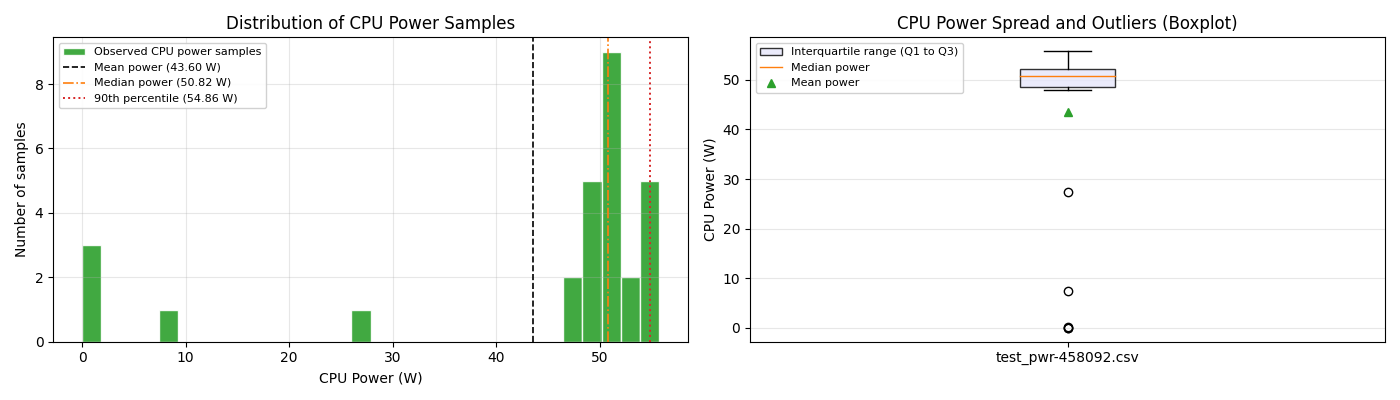

In [18]:
# Power distribution and outlier view
run = pj_runs[pj_idx]
power = run['power']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histogram with reference statistics
ax1.hist(power, bins=30, color='tab:green', edgecolor='white', alpha=0.9,
         label='Observed CPU power samples')
mean_p = power.mean()
med_p = np.median(power)
p90_p = np.percentile(power, 90)
ax1.axvline(mean_p, color='black', linestyle='--', linewidth=1.2,
            label=f'Mean power ({mean_p:.2f} W)')
ax1.axvline(med_p, color='tab:orange', linestyle='-.', linewidth=1.2,
            label=f'Median power ({med_p:.2f} W)')
ax1.axvline(p90_p, color='tab:red', linestyle=':', linewidth=1.4,
            label=f'90th percentile ({p90_p:.2f} W)')
ax1.set_title('Distribution of CPU Power Samples')
ax1.set_xlabel('CPU Power (W)')
ax1.set_ylabel('Number of samples')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8, loc='upper left', framealpha=0.9)

# Boxplot (whiskers/outliers) + legend text
bp = ax2.boxplot([power], vert=True, showmeans=True, patch_artist=True)
bp['boxes'][0].set(facecolor='lavender', alpha=0.8)
ax2.set_title('CPU Power Spread and Outliers (Boxplot)')
ax2.set_ylabel('CPU Power (W)')
ax2.set_xticks([1])
ax2.set_xticklabels([run['path'].name])
ax2.grid(True, axis='y', alpha=0.3)
ax2.legend([
    bp['boxes'][0], bp['medians'][0], bp['means'][0]
], [
    'Interquartile range (Q1 to Q3)',
    'Median power',
    'Mean power'
], fontsize=8, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()


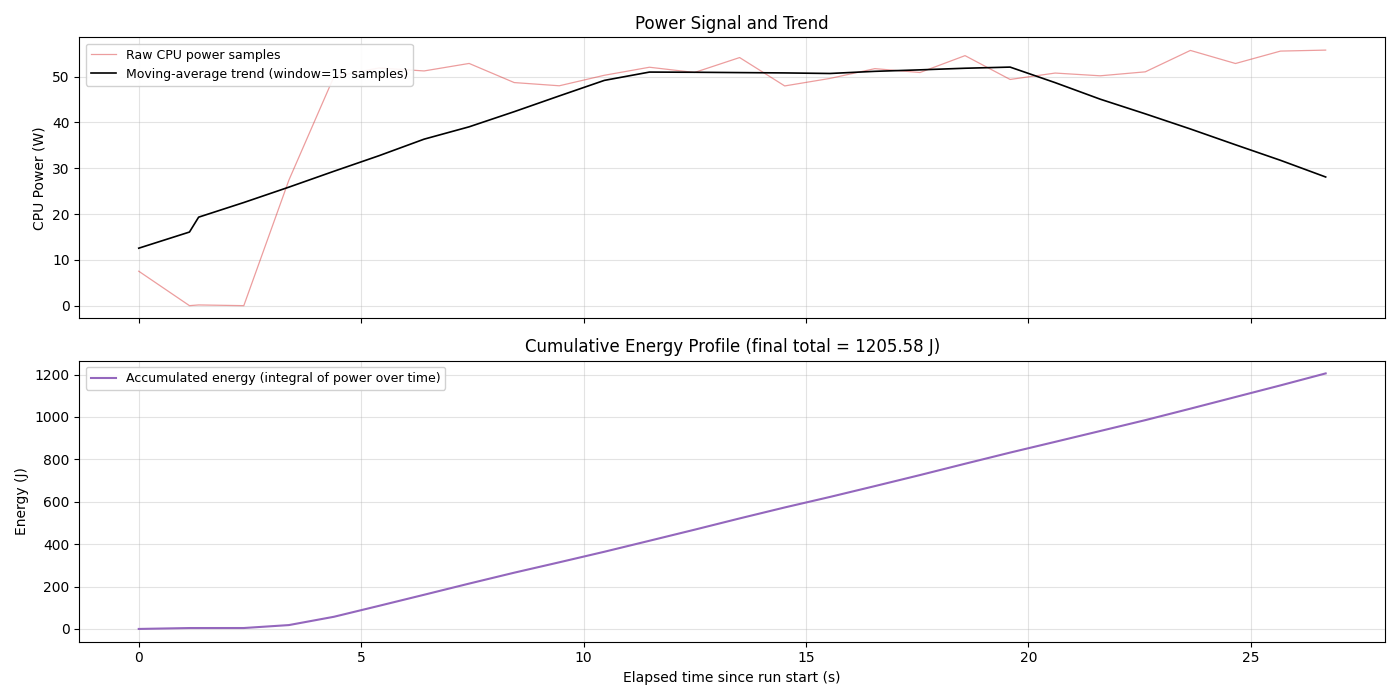

In [19]:
# Cumulative energy over time and smoothed power
run = pj_runs[pj_idx]
t = run['t_sec']
p = run['power']

cum_energy = np.zeros_like(t)
if len(t) > 1:
    dt = np.diff(t)
    cum_energy[1:] = np.cumsum(0.5 * (p[1:] + p[:-1]) * dt)

window = min(15, len(p))
if window >= 3:
    kernel = np.ones(window, dtype=float) / float(window)
    p_smooth = np.convolve(p, kernel, mode='same')
else:
    p_smooth = p

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
raw_line, = ax1.plot(t, p, color='tab:red', alpha=0.45, linewidth=0.9,
                     label='Raw CPU power samples')
smooth_line, = ax1.plot(t, p_smooth, color='black', linewidth=1.2,
                        label=f'Moving-average trend (window={window} samples)')
ax1.set_ylabel('CPU Power (W)')
ax1.set_title('Power Signal and Trend')
ax1.legend([raw_line, smooth_line], [raw_line.get_label(), smooth_line.get_label()],
           fontsize=9, loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.35)

energy_line, = ax2.plot(t, cum_energy, color='tab:purple', linewidth=1.5,
                        label='Accumulated energy (integral of power over time)')
ax2.set_xlabel('Elapsed time since run start (s)')
ax2.set_ylabel('Energy (J)')
ax2.set_title(f"Cumulative Energy Profile (final total = {cum_energy[-1]:.2f} J)")
ax2.legend([energy_line], [energy_line.get_label()], fontsize=9, loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


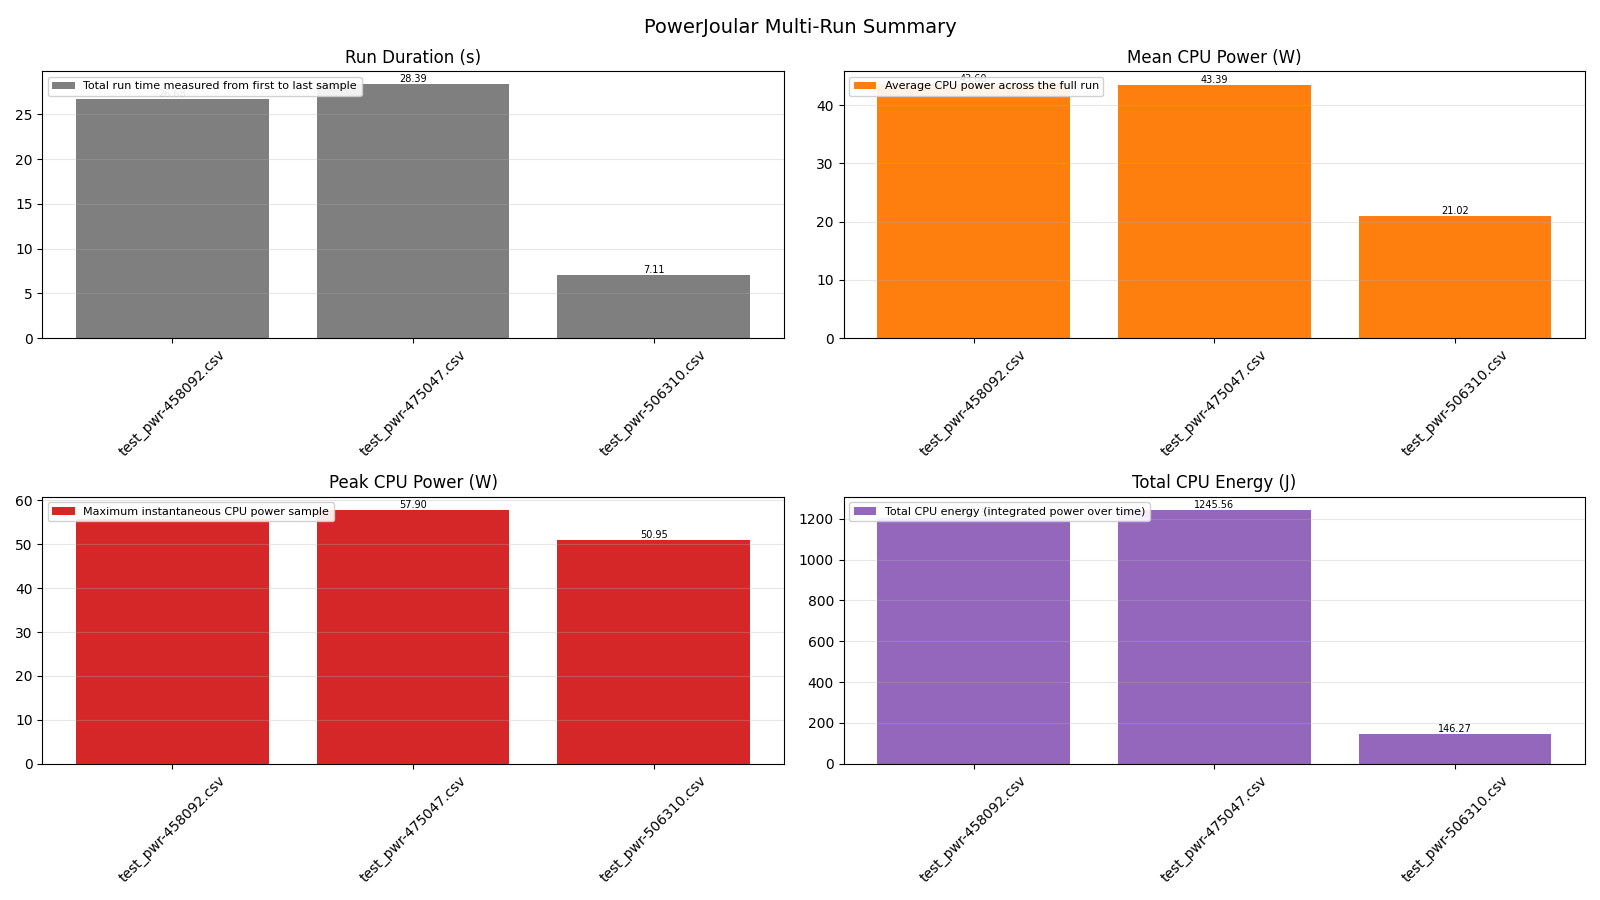

In [20]:
# Compare all runs: duration, mean power, peak power, total energy
names = [r['path'].name for r in pj_runs]
dur = np.array([r['duration_s'] for r in pj_runs], dtype=float)
p_mean = np.array([r['power'].mean() for r in pj_runs], dtype=float)
p_peak = np.array([r['power'].max() for r in pj_runs], dtype=float)
energy = np.array([r['energy_j'] for r in pj_runs], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

bars0 = axes[0].bar(names, dur, color='tab:gray', label='Total run time measured from first to last sample')
axes[0].set_title('Run Duration (s)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(fontsize=8, loc='upper left', framealpha=0.9)

bars1 = axes[1].bar(names, p_mean, color='tab:orange', label='Average CPU power across the full run')
axes[1].set_title('Mean CPU Power (W)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(fontsize=8, loc='upper left', framealpha=0.9)

bars2 = axes[2].bar(names, p_peak, color='tab:red', label='Maximum instantaneous CPU power sample')
axes[2].set_title('Peak CPU Power (W)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, axis='y', alpha=0.3)
axes[2].legend(fontsize=8, loc='upper left', framealpha=0.9)

bars3 = axes[3].bar(names, energy, color='tab:purple', label='Total CPU energy (integrated power over time)')
axes[3].set_title('Total CPU Energy (J)')
axes[3].tick_params(axis='x', rotation=45)
axes[3].grid(True, axis='y', alpha=0.3)
axes[3].legend(fontsize=8, loc='upper left', framealpha=0.9)

for ax, vals in zip(axes, [dur, p_mean, p_peak, energy]):
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('PowerJoular Multi-Run Summary', fontsize=14)
plt.tight_layout()
plt.show()


# GPU Analysis (nvidia-smi)

Load and visualize GPU telemetry exported by `nvidia-smi` (`--gpu_file ...`).


In [21]:
import csv
from datetime import datetime
from pathlib import Path

# GPU log folder (supports files with and without .csv extension)
gpu_dir = Path('/home/moveEnetFlow/pwr_gpu_file')


def _find_col(fieldnames, required_substr):
    key = required_substr.lower()
    for name in fieldnames:
        if key in name.lower():
            return name
    raise KeyError(f"Could not find column containing: {required_substr!r}. Available: {fieldnames}")


def _to_float_or_nan(value):
    text = str(value).strip()
    if text in ('', '[No data]', 'No data', 'N/A', 'na', 'nan'):
        return np.nan
    return float(text)


def _parse_ts(text):
    text = str(text).strip()
    for fmt in ('%Y/%m/%d %H:%M:%S.%f', '%Y-%m-%d %H:%M:%S.%f', '%Y/%m/%d %H:%M:%S', '%Y-%m-%d %H:%M:%S'):
        try:
            return datetime.strptime(text, fmt)
        except ValueError:
            pass
    raise ValueError(f'Unsupported timestamp format: {text!r}')


def load_gpu_log(path):
    rows = []
    with open(path, newline='') as f:
        reader = csv.DictReader(f, skipinitialspace=True)
        if reader.fieldnames is None:
            raise ValueError(f'No CSV header in {path}')
        cols = [c.strip() for c in reader.fieldnames]

        c_ts = _find_col(cols, 'timestamp')
        c_idx = _find_col(cols, 'index')
        c_name = _find_col(cols, 'name')
        c_gpu_util = _find_col(cols, 'utilization.gpu')
        c_mem_util = _find_col(cols, 'utilization.memory')
        c_power = _find_col(cols, 'power.draw')
        c_temp = _find_col(cols, 'temperature.gpu')

        for r in reader:
            rr = {k.strip(): v for k, v in r.items()}
            rows.append((
                _parse_ts(rr[c_ts]),
                int(float(str(rr[c_idx]).strip())),
                str(rr[c_name]).strip(),
                _to_float_or_nan(rr[c_gpu_util]),
                _to_float_or_nan(rr[c_mem_util]),
                _to_float_or_nan(rr[c_power]),
                _to_float_or_nan(rr[c_temp]),
            ))

    if not rows:
        raise ValueError(f'No data rows in {path}')

    t0 = rows[0][0]
    t_sec = np.array([(r[0] - t0).total_seconds() for r in rows], dtype=float)
    gpu_util = np.array([r[3] for r in rows], dtype=float)
    mem_util = np.array([r[4] for r in rows], dtype=float)
    power = np.array([r[5] for r in rows], dtype=float)
    temp = np.array([r[6] for r in rows], dtype=float)

    # Estimate energy from available power samples (NaN -> 0 for integration)
    energy_j = np.trapz(np.nan_to_num(power, nan=0.0), t_sec) if len(t_sec) > 1 else 0.0

    return {
        'path': path,
        'gpu_index': rows[0][1],
        'gpu_name': rows[0][2],
        't_sec': t_sec,
        'gpu_util': gpu_util,
        'mem_util': mem_util,
        'power': power,
        'temp': temp,
        'energy_j': float(energy_j),
        'duration_s': float(t_sec[-1] - t_sec[0]) if len(t_sec) > 1 else 0.0,
    }


gpu_files = sorted([p for p in gpu_dir.glob('*') if p.is_file()])
if not gpu_files:
    raise FileNotFoundError(f'No GPU log files found in {gpu_dir}')

gpu_runs = [load_gpu_log(p) for p in gpu_files]
print(f'Loaded {len(gpu_runs)} GPU log file(s) from {gpu_dir}')
for r in gpu_runs:
    valid_power = np.isfinite(r['power'])
    mean_power = np.nanmean(r['power']) if np.any(valid_power) else np.nan
    print(f"- {r['path'].name}: GPU {r['gpu_index']} ({r['gpu_name']}), duration={r['duration_s']:.2f}s, mean_power={mean_power:.2f}W, energy={r['energy_j']:.2f}J")


Loaded 1 GPU log file(s) from /home/moveEnetFlow/pwr_gpu_file
- test_pwr: GPU 0 (NVIDIA RTX 2000 Ada Generation Laptop GPU), duration=27.00s, mean_power=12.93W, energy=348.29J


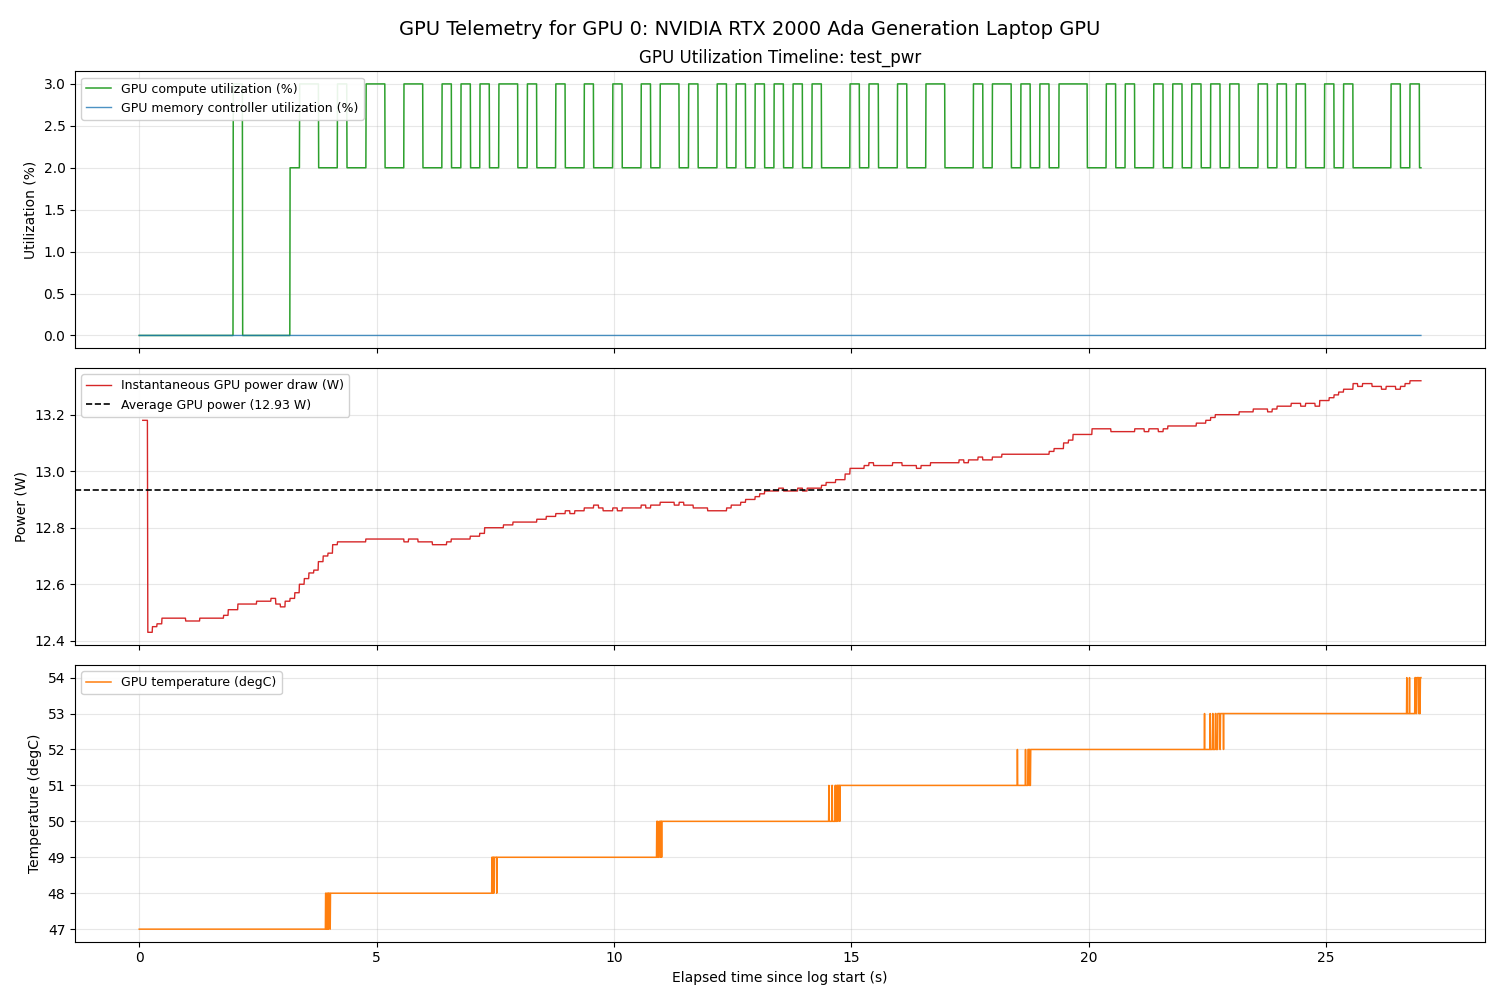

In [22]:
# Detailed timeline for one GPU run
gpu_idx = 0
run = gpu_runs[gpu_idx]

t = run['t_sec']
gpu_u = run['gpu_util']
mem_u = run['mem_util']
pow_w = run['power']
temp_c = run['temp']

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(t, gpu_u, color='tab:green', linewidth=1.1, label='GPU compute utilization (%)')
axes[0].plot(t, mem_u, color='tab:blue', linewidth=1.0, alpha=0.8, label='GPU memory controller utilization (%)')
axes[0].set_ylabel('Utilization (%)')
axes[0].set_title(f"GPU Utilization Timeline: {run['path'].name}")
axes[0].legend(fontsize=9, loc='upper left', framealpha=0.9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, pow_w, color='tab:red', linewidth=1.0, label='Instantaneous GPU power draw (W)')
if np.any(np.isfinite(pow_w)):
    mean_pow = np.nanmean(pow_w)
    axes[1].axhline(mean_pow, color='black', linestyle='--', linewidth=1.2,
                    label=f'Average GPU power ({mean_pow:.2f} W)')
axes[1].set_ylabel('Power (W)')
axes[1].legend(fontsize=9, loc='upper left', framealpha=0.9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, temp_c, color='tab:orange', linewidth=1.1,
             label='GPU temperature (degC)')
axes[2].set_xlabel('Elapsed time since log start (s)')
axes[2].set_ylabel('Temperature (degC)')
axes[2].legend(fontsize=9, loc='upper left', framealpha=0.9)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"GPU Telemetry for GPU {run['gpu_index']}: {run['gpu_name']}", fontsize=14)
plt.tight_layout()
plt.show()


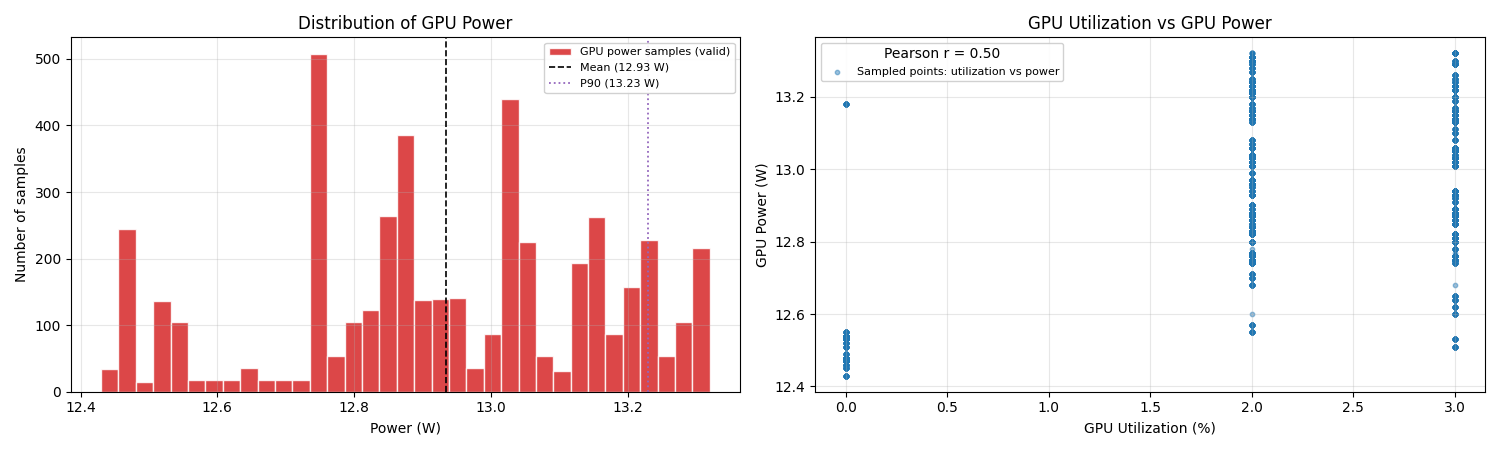

In [23]:
# GPU power distribution + utilization-to-power relationship
run = gpu_runs[gpu_idx]
valid = np.isfinite(run['power'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

if np.any(valid):
    p = run['power'][valid]
    ax1.hist(p, bins=35, color='tab:red', alpha=0.85, edgecolor='white',
             label='GPU power samples (valid)')
    ax1.axvline(np.mean(p), color='black', linestyle='--', linewidth=1.2,
                label=f'Mean ({np.mean(p):.2f} W)')
    ax1.axvline(np.percentile(p, 90), color='tab:purple', linestyle=':', linewidth=1.3,
                label=f'P90 ({np.percentile(p, 90):.2f} W)')
    ax1.legend(fontsize=8, loc='upper right', framealpha=0.9)
else:
    ax1.text(0.5, 0.5, 'No valid GPU power samples', ha='center', va='center')

ax1.set_title('Distribution of GPU Power')
ax1.set_xlabel('Power (W)')
ax1.set_ylabel('Number of samples')
ax1.grid(True, alpha=0.3)

valid_scatter = np.isfinite(run['gpu_util']) & np.isfinite(run['power'])
if np.any(valid_scatter):
    x = run['gpu_util'][valid_scatter]
    y = run['power'][valid_scatter]
    ax2.scatter(x, y, s=10, alpha=0.45, color='tab:blue',
                label='Sampled points: utilization vs power')
    corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    ax2.legend(title=f'Pearson r = {corr:.2f}', fontsize=8, loc='upper left', framealpha=0.9)
else:
    ax2.text(0.5, 0.5, 'No valid paired samples', ha='center', va='center')

ax2.set_title('GPU Utilization vs GPU Power')
ax2.set_xlabel('GPU Utilization (%)')
ax2.set_ylabel('GPU Power (W)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


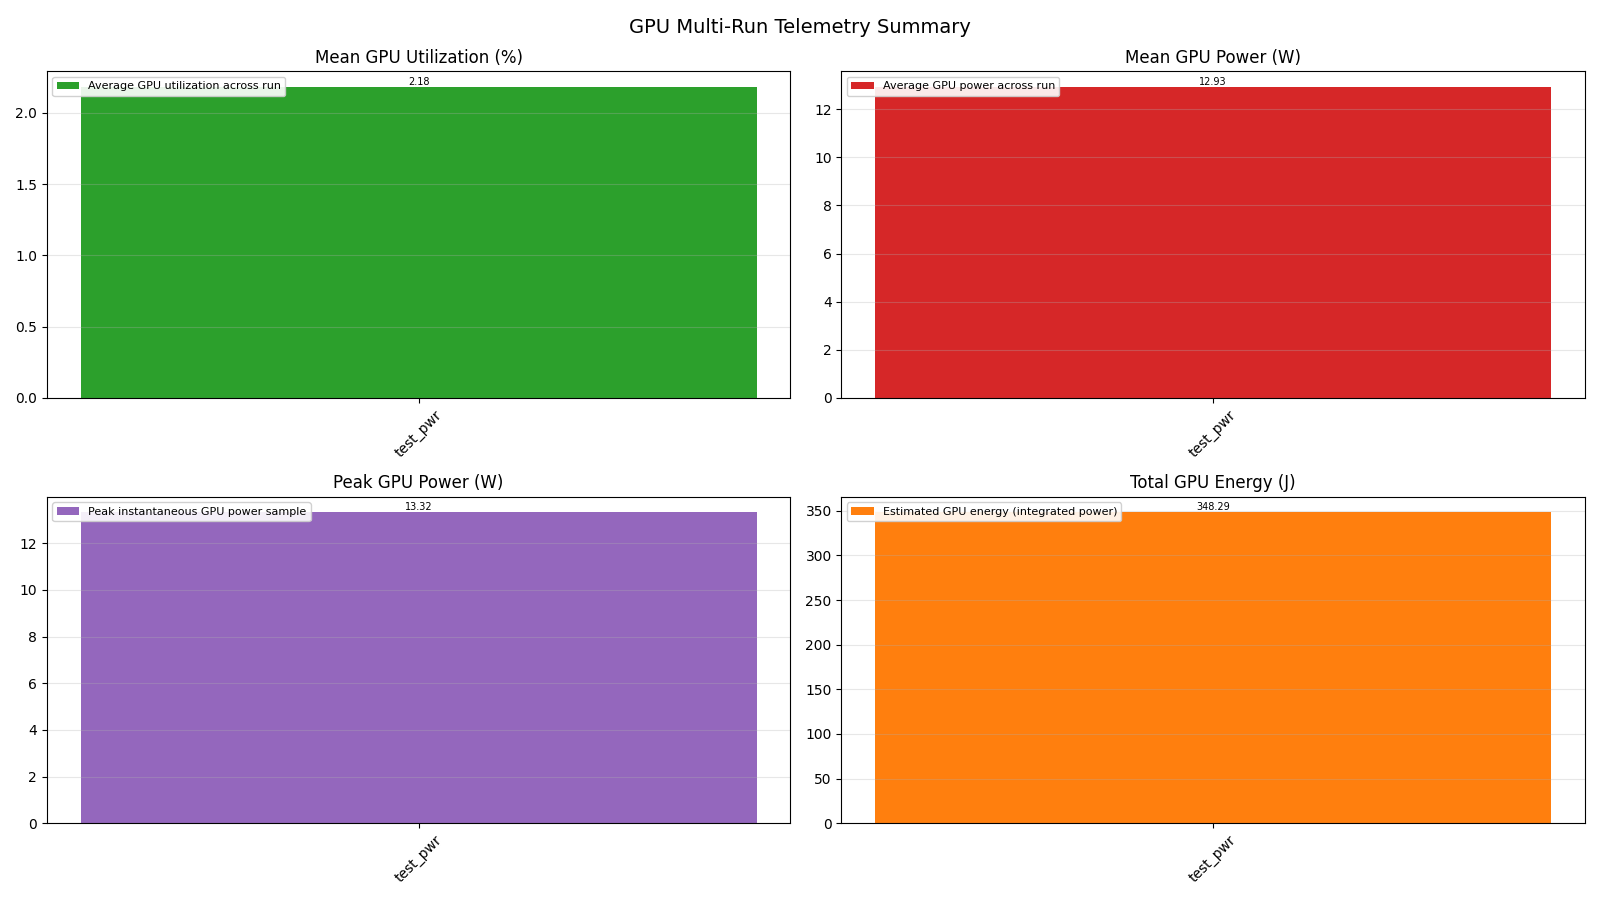

In [24]:
# Multi-run GPU summary
names = [r['path'].name for r in gpu_runs]
duration = np.array([r['duration_s'] for r in gpu_runs], dtype=float)
mean_gpu_util = np.array([np.nanmean(r['gpu_util']) for r in gpu_runs], dtype=float)
mean_gpu_power = np.array([np.nanmean(r['power']) for r in gpu_runs], dtype=float)
peak_gpu_power = np.array([np.nanmax(r['power']) for r in gpu_runs], dtype=float)
energy = np.array([r['energy_j'] for r in gpu_runs], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

axes[0].bar(names, mean_gpu_util, color='tab:green', label='Average GPU utilization across run')
axes[0].set_title('Mean GPU Utilization (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(fontsize=8, loc='upper left', framealpha=0.9)

axes[1].bar(names, mean_gpu_power, color='tab:red', label='Average GPU power across run')
axes[1].set_title('Mean GPU Power (W)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(fontsize=8, loc='upper left', framealpha=0.9)

axes[2].bar(names, peak_gpu_power, color='tab:purple', label='Peak instantaneous GPU power sample')
axes[2].set_title('Peak GPU Power (W)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, axis='y', alpha=0.3)
axes[2].legend(fontsize=8, loc='upper left', framealpha=0.9)

axes[3].bar(names, energy, color='tab:orange', label='Estimated GPU energy (integrated power)')
axes[3].set_title('Total GPU Energy (J)')
axes[3].tick_params(axis='x', rotation=45)
axes[3].grid(True, axis='y', alpha=0.3)
axes[3].legend(fontsize=8, loc='upper left', framealpha=0.9)

for ax, vals in zip(axes, [mean_gpu_util, mean_gpu_power, peak_gpu_power, energy]):
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('GPU Multi-Run Telemetry Summary', fontsize=14)
plt.tight_layout()
plt.show()


# Combined CPU + GPU Analysis

This section combines PowerJoular (CPU) and `nvidia-smi` (GPU) runs for total compute power/energy views.


In [25]:
# Pair CPU and GPU runs by file order (or shortest available count)
if 'pj_runs' not in globals() or 'gpu_runs' not in globals():
    raise RuntimeError('Run CPU (PowerJoular) and GPU loading cells first.')

pair_count = min(len(pj_runs), len(gpu_runs))
if pair_count == 0:
    raise RuntimeError('No CPU/GPU runs available to combine.')

print(f'Combining {pair_count} CPU/GPU run pair(s) by index order.')
for i in range(pair_count):
    print(f"Pair {i}: CPU={pj_runs[i]['path'].name} | GPU={gpu_runs[i]['path'].name}")


Combining 1 CPU/GPU run pair(s) by index order.
Pair 0: CPU=test_pwr-458092.csv | GPU=test_pwr


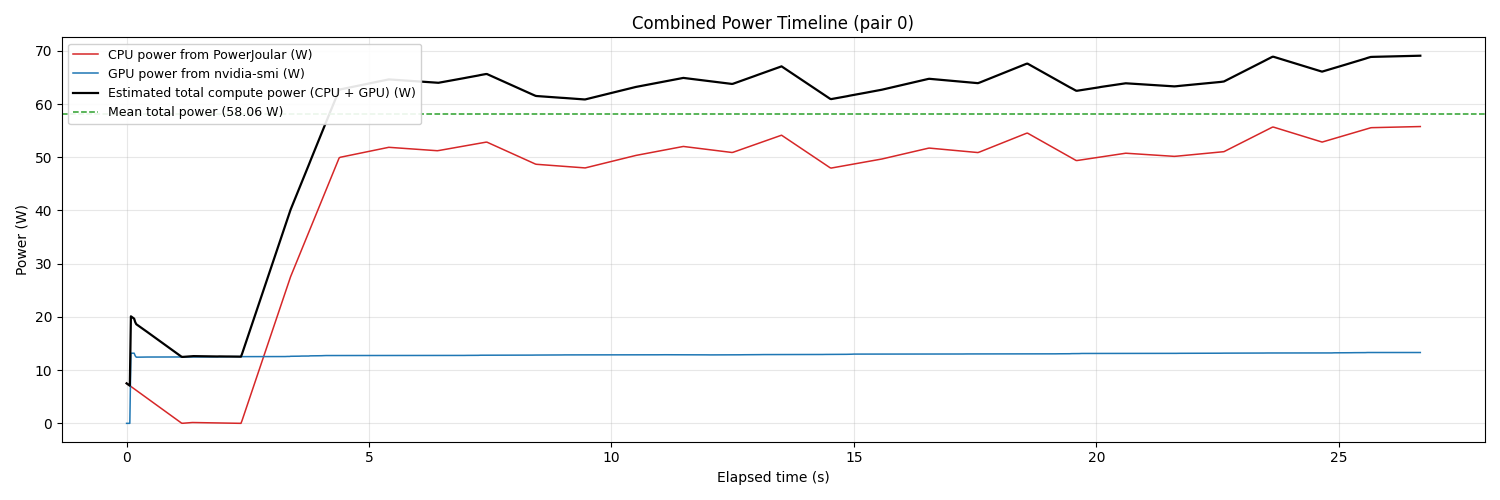

In [26]:
# Combined timeline for one pair: CPU power, GPU power, and total power
pair_idx = 0
cpu = pj_runs[pair_idx]
gpu = gpu_runs[pair_idx]

# Shift both timelines to start at 0 independently; interpolate to a common axis
t_end = min(np.nanmax(cpu['t_sec']), np.nanmax(gpu['t_sec']))
if not np.isfinite(t_end) or t_end <= 0:
    raise ValueError('Insufficient overlap between CPU and GPU time ranges.')

n_points = 1200
t_common = np.linspace(0.0, t_end, n_points)

cpu_power = np.interp(t_common, cpu['t_sec'], cpu['power'])
gpu_power_raw = np.nan_to_num(gpu['power'], nan=0.0)
gpu_power = np.interp(t_common, gpu['t_sec'], gpu_power_raw)
total_power = cpu_power + gpu_power

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(t_common, cpu_power, color='tab:red', linewidth=1.1, label='CPU power from PowerJoular (W)')
ax.plot(t_common, gpu_power, color='tab:blue', linewidth=1.1, label='GPU power from nvidia-smi (W)')
ax.plot(t_common, total_power, color='black', linewidth=1.6, label='Estimated total compute power (CPU + GPU) (W)')

ax.axhline(np.mean(total_power), color='tab:green', linestyle='--', linewidth=1.1,
           label=f'Mean total power ({np.mean(total_power):.2f} W)')

ax.set_title(f"Combined Power Timeline (pair {pair_idx})")
ax.set_xlabel('Elapsed time (s)')
ax.set_ylabel('Power (W)')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


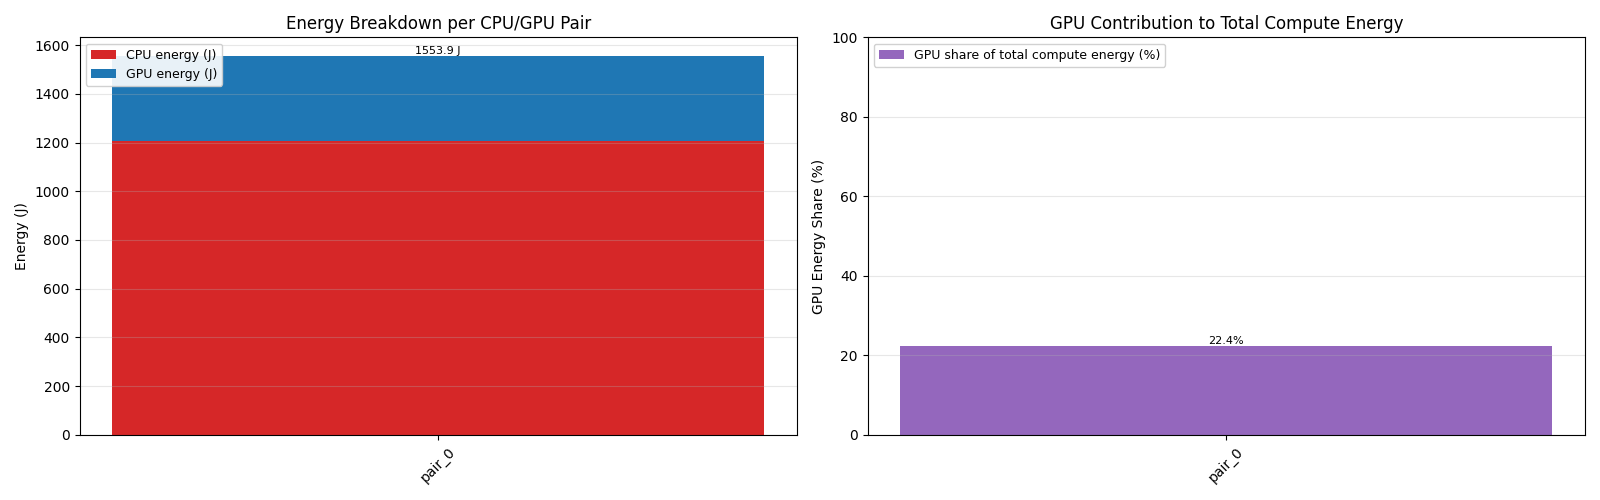

In [27]:
# Energy breakdown per pair: CPU vs GPU vs Total
pair_labels = []
cpu_energy = []
gpu_energy = []
total_energy = []

for i in range(pair_count):
    cpu = pj_runs[i]
    gpu = gpu_runs[i]

    e_cpu = float(cpu['energy_j'])
    e_gpu = float(gpu['energy_j'])
    e_tot = e_cpu + e_gpu

    pair_labels.append(f'pair_{i}')
    cpu_energy.append(e_cpu)
    gpu_energy.append(e_gpu)
    total_energy.append(e_tot)

cpu_energy = np.array(cpu_energy)
gpu_energy = np.array(gpu_energy)
total_energy = np.array(total_energy)

x = np.arange(pair_count)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Stacked energy bars
ax1.bar(x, cpu_energy, color='tab:red', label='CPU energy (J)')
ax1.bar(x, gpu_energy, bottom=cpu_energy, color='tab:blue', label='GPU energy (J)')
ax1.set_xticks(x)
ax1.set_xticklabels(pair_labels, rotation=45)
ax1.set_ylabel('Energy (J)')
ax1.set_title('Energy Breakdown per CPU/GPU Pair')
ax1.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax1.grid(True, axis='y', alpha=0.3)

# Share of GPU energy
gpu_share = np.divide(gpu_energy, total_energy, out=np.zeros_like(gpu_energy), where=total_energy > 0) * 100.0
ax2.bar(x, gpu_share, color='tab:purple', label='GPU share of total compute energy (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(pair_labels, rotation=45)
ax2.set_ylabel('GPU Energy Share (%)')
ax2.set_ylim(0, 100)
ax2.set_title('GPU Contribution to Total Compute Energy')
ax2.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax2.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(total_energy):
    ax1.text(i, v, f'{v:.1f} J', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(gpu_share):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Compact table-style printout of combined efficiency metrics
print('pair | cpu_mean_W | gpu_mean_W | total_mean_W | cpu_E_J | gpu_E_J | total_E_J')
for i in range(pair_count):
    cpu = pj_runs[i]
    gpu = gpu_runs[i]
    cpu_mean = float(np.mean(cpu['power']))
    gpu_mean = float(np.nanmean(gpu['power']))
    total_mean = cpu_mean + gpu_mean
    cpu_E = float(cpu['energy_j'])
    gpu_E = float(gpu['energy_j'])
    print(f"{i:>4} | {cpu_mean:>10.2f} | {gpu_mean:>10.2f} | {total_mean:>12.2f} | {cpu_E:>7.2f} | {gpu_E:>7.2f} | {cpu_E + gpu_E:>9.2f}")
